In [1]:
import sys
sys.path.append('./lib')
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
import fitlib as ftl

In [2]:
# Load instrument

instr_name = 'litebird_full'
instr = np.load('./lib/instr_dict/%s.npy'%instr_name, allow_pickle=True).item()
freq = np.tile(instr['frequencies'], 2)
print('frequencies:', freq)

Nfreqs = len(freq)
Ngrid = 50

bw = np.tile(instr['bandwidths'], 2)
freq_grids = np.zeros((Nfreqs, Ngrid))
for i in range(Nfreqs):
    freq_grids[i] = np.geomspace(freq[i]-bw[i]/2, freq[i]+bw[i]/2, Ngrid)
freq = freq_grids

frequencies: [ 40  50  60  68  68  78  78  89  89 100 119 140 100 119 140 166 195 195
 235 280 337 402  40  50  60  68  68  78  78  89  89 100 119 140 100 119
 140 166 195 195 235 280 337 402]


In [3]:
# Load cross-spectra

nside = 64
lmax=2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

DLcross = np.load('/pscratch/sd/s/svinzl/B_modes_project/power_spectra/DLcross_nside64_fsky0.7_scale10_Nlbin10_dbsbc_gaussbeam_bandpass_HM.npy')[:, :, :Nbins]
DLnoise = np.load('/pscratch/sd/s/svinzl/B_modes_project/power_spectra/DLnoise_nside64_fsky0.7_scale10_Nlbin10_gaussbeam_HM.npy')[:, :, :Nbins]

N, Ncross = DLcross.shape[:2]

In [4]:
# Inverse covmat

covmat = np.load('/pscratch/sd/s/svinzl/B_modes_project/covariances/cov_Nmt-fg_nside64_fsky0.7_scale10_Nlbin10_dbsbc_gaussbeam_bandpass_HM.npy')[:Ncross*Nbins, :Ncross*Nbins]
N_inv = np.linalg.inv(covmat)

In [5]:
# Build model

betabar = 1.531
tempbar = 20.209
betasbar = -2.997

nu0d = 402
nu0s = 40

freq_pairs = np.array([(i, j) for i in range(Nfreqs) for j in range(i, Nfreqs)])
nu_i = freq[freq_pairs[:, 0]]
nu_j = freq[freq_pairs[:, 1]]

Ncross = len(nu_i)

DLmoms = np.load('analytical_mom_nside64_fsky0.7_scale10_Nlbin10_d1s1_1.53120.209-2.997_40240.npy', allow_pickle=True).item()
DL_lens, DL_tens = ftl.getDL_cmb(nside=64, Nlbin=10, mode='BB', cmb_e2e=True)

DLmodel = np.zeros((Ncross, Nbins))

for i in range(Nbins):
    p = [DLmoms['A_d'][i], betabar, 1/tempbar, DLmoms['A_s'][i], betasbar, DLmoms['A_sd'][i], # order 0
         DLmoms['Aw1b'][i], DLmoms['w1bw1b'][i], DLmoms['Aw1t'][i], DLmoms['w1bw1t'][i], DLmoms['w1tw1t'][i], # dust moments
         DLmoms['Asw1bs'][i], DLmoms['w1bsw1bs'][i], # sync moments
         DLmoms['Asw1b'][i], DLmoms['Asw1t'][i], DLmoms['Aw1bs'][i], DLmoms['w1bw1bs'][i], DLmoms['w1tw1bs'][i], # dust x sync moments
         0] # r

    DLmodel[:, i] = ftl.func_ds_o1bts(p, x1=nu_i, x2=nu_j, nu0d=nu0d, nu0s=nu0s, ell=i, DL_lensbin=DL_lens, DL_tens=DL_tens)

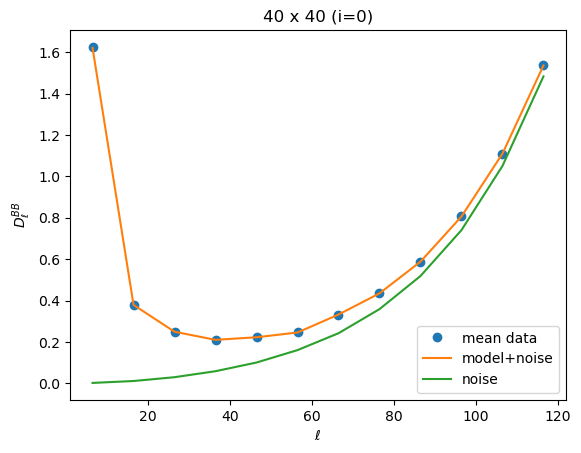

In [9]:
idx = 0
nu1 = int((nu_i[idx, 0] + nu_i[idx, -1]) / 2)
nu2 = int((nu_j[idx, 0] + nu_j[idx, -1]) / 2)

plt.plot(leff, np.mean(DLcross, axis=0)[idx], 'o', label='mean data')
plt.plot(leff, DLmodel[idx] + np.mean(DLnoise, axis=0)[idx], label='model+noise')
plt.plot(leff, np.mean(DLnoise, axis=0)[idx], label='noise')
plt.title(f'{nu1} x {nu2} (i={idx})')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$')
plt.legend()
plt.show()

In [7]:
# Compute chi2r

chi2r = np.zeros(N)
for i in range(N):
    data = np.concatenate(DLcross[i].T)
    noise = np.concatenate(DLnoise[i].T)
    model = np.concatenate(DLmodel.T)

    res = (data - noise - model)
    dof = data.size - (len(p)*Nbins)

    chi2r[i] = (res.T @ N_inv @ res) / dof

print('mean chi2r:', np.mean(chi2r))

mean chi2r: 0.959123983453404


In [8]:
np.save('DLcross_nside64_fsky0.7_scale10_Nlbin10_dbsbc_gaussbeam_bandpass_HM.npy', DLcross)